In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import ast

In [80]:
raw_data=pd.read_csv("C:\\Users\\locos\\Documents\\Code\\Ciampitti-Lab\\PublicationAnalysis\\data\\machine_learning_data\\openalex_output\\works.csv")
df = raw_data.copy()

In [81]:
raw_data.columns

Index(['openalex_id', 'openalex_url', 'doi', 'title', 'publication_year',
       'publication_date', 'type', 'cited_by_count', 'fwci',
       'citation_percentile_value', 'cited_by_api_url', 'authors_count',
       'countries_distinct_count', 'institutions_distinct_count',
       'corresponding_author_ids', 'corresponding_institution_ids',
       'queried_author_id', 'queried_author_position',
       'queried_author_is_corresponding', 'queried_author_raw_name',
       'queried_author_raw_affiliation', 'is_oa', 'oa_status', 'source_id',
       'source_display_name', 'source_issn_l', 'source_issn', 'source_type',
       'source_is_oa', 'source_host_org_name', 'apc_list_value_usd',
       'apc_paid_value_usd', 'primary_topic_id', 'primary_topic_name',
       'primary_topic_score', 'primary_subfield_id', 'primary_subfield_name',
       'primary_field_id', 'primary_field_name', 'all_topics', 'keywords',
       'sustainable_development_goals', 'referenced_works_count',
       'referenced_wor

In [82]:
print(df.source_display_name)
df.source_display_name.fillna("Unandentified", inplace=True)
print(len(df.source_display_name.unique()))


0                        Global Change Biology
1                                Food Security
2                            Geoderma Regional
3                             Agronomy Journal
4       Journal of Soil and Water Conservation
                         ...                  
2444                                       NaN
2445                                       NaN
2446                                       NaN
2447                                       NaN
2448                                       NaN
Name: source_display_name, Length: 2449, dtype: object
407


C:\Users\locos\AppData\Local\Temp\ipykernel_18892\2857081417.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.source_display_name.fillna("Unandentified", inplace=True)


In [83]:
peer_reviewed = {'Global Change Biology',
'Food Security',
'Geoderma Regional',
'Agronomy Journal',
'Journal of Soil and Water Conservation',
'Soil and Tillage Research',
'Philosophical Transactions of the Royal Society B Biological Sciences',
'Current Climate Change Reports',
'Soil Science & Plant Nutrition',
'Soil Systems',
'International Soil and Water Conservation Research',
'Geoderma',
'South African Journal of Plant and Soil',
'Frontiers in Sustainable Food Systems',
'European Journal of Soil Science',
'Pedosphere',
'Climate Change',
'Applied Sciences',
'Crop Science',
'Current Sustainable/Renewable Energy Reports',
'Nature Communications',
'Soil Biology and Biochemistry',
'Science of the Total Environment',
'Land Degradation and Development',
'Earth-Science Reviews',
'Frontiers of Agricultural Science and Engineering',
'Biogeosciences',
'Trends in Plant Science',
'Journal of Integrative Agriculture',
'Annual Review of Environment and Resources',
'Agriculture, Ecosystems & Environment',
'Philosophical Transactions of the Royal Society A',
'Earth System Science Data',
'Proceedings of the Royal Society B',
'GCB Bioenergy',
'Veterinary Record',
'One Earth',
'Architectural History',
'Journalism History',
'Australian Forestry',
'Nature Reviews Earth & Environment',
'Nature Geoscience',
'Communications Biology',
'Geochimica et Cosmochimica Acta',
'Palgrave Communications',
'ACS Sustainable Chemistry & Engineering',
'Waste Management',
'Nature',
'Journal of Environmental Quality',
'Scientific Reports',
'New Phytologist',
'Chemosphere',
'Applied Soil Ecology',
'Nutrient Cycling in Agroecosystems',
'Biochar',
'Soil Science',
'PLOS Global Public Health',
'Water',
'Ecology Letters',
'Frontiers in Microbiology',
'Frontiers in Plant Science',  
'Frontiers in Agronomy',
'PLoS ONE',
'Journal of Agricultural and Food Chemistry',
'Journal of Plant Nutrition and Soil Science',
'Plant and Soil',
'Journal of Cereal Science',
'Panoeconomicus',
'Annual Review of Ecology, Evolution, and Systematics',
'Nature Reviews Microbiology',
'Science Advances',
'Nature Microbiology',
'Field Crops Research',
'Environmental Science & Technology',
'Functional Ecology',
'Journal of Applied Ecology',
'SOIL',
'Nature Sustainability',
'Science',
'Global Sustainability',
'International Journal of Environmental Research and Public Health',
'Agriculture and Human Values',
'Respirology',
'Sustainability',
'Geoscientific Model Development',
'AMBIO',
'Earth’s Future',
'Outlook on Agriculture',
'NJAS – Wageningen Journal of Life Sciences',
'Global Food Security',
'Agricultural Systems',
'Ecosystem Services',
'Journal of Agricultural Education and Extension',
'Environmental Innovation and Societal Transitions',
'Food Policy',
'Journal of Rural Studies',
'Sociologia Ruralis',
'International Journal of Agricultural Sustainability',
'New Zealand Economic Papers',
'Journal of Technology Management & Innovation',
'Agriculture',
'Journal of Environmental Management',
'Agricultural Water Management',
'Industrial Crops and Products',
'Human and Ecological Risk Assessment',
'Scientia Horticulturae',
'Environmental Science and Pollution Research',
'Environmental Monitoring and Assessment',
'Journal of Soil Science and Plant Nutrition',
'Weed Biology and Management',
'Plant Science',
'Pest Management Science',
'Biological Agriculture & Horticulture',
'Environment, Development and Sustainability',
'Crop Protection',
'Journal of Plant Growth Regulation',
'Biologia',
'International Journal of Pest Management',
'Renewable and Sustainable Energy Reviews',
'Land Use Policy',
'Horticulturae',
'Weed Technology',
'Plant Species Biology',
'Experimental Agriculture',
'National Science Review',
'Environmental Pollution',
'The Crop Journal',
'Atmospheric Chemistry and Physics',
'European Journal of Agronomy',
'Food and Energy Security',
'Frontiers in Nutrition',
'Critical Reviews in Environmental Science and Technology',
'Remote Sensing',
'Biogeochemistry',
'Journal of Hydrology',
'Soil Security',
'CATENA',
'Remote Sensing: Applications Society and Environment',
'FEMS Microbiology Ecology',
'Soil Science Society of America Journal',
'Grass and Forage Science',
'CABI Reviews',
'Agricultural & Environmental Letters',
'Agronomy',
'Journal of Animal Science',
'Italian Journal of Agronomy',
'Frontiers in Climate',
'Frontiers in Environmental Science',
'Communications Earth & Environment',
'Physica Scripta',
'Journal of Hazardous Materials Advances',
'BMC Plant Biology',
'International Journal of Molecular Sciences',
'Plant Physiology and Biochemistry',
'Biology',
'Materials Today Bio',
'Nature Plants',
'Current Opinion in Plant Biology',
'Functional Plant Biology',
'Cells',
'Proteomes',
'Physiologia Plantarum',
'Plant Stress',
'Plants',
'Frontiers in Genetics',
'Hydrology and Earth System Sciences',
'Environmental and Experimental Botany',
'Genes',
'Journal of Proteomics',
'Cahiers Agricultures',
'ISPRS Journal of Photogrammetry and Remote Sensing',
'E&G Quaternary Science Journal',
'Climate of the Past',
'Technical Gazette',
'American Naturalist',
'Biodiversitas',
'Ecology and Evolution',
'Royal Society Open Science',
'Journal of Experimental Botany',
'Elementa: Science of the Anthropocene',
'Nature Food',
'The Lancet Planetary Health',
'Nature Human Behaviour',
'European Journal of Integrative Medicine',
'Renewable Energy',
'Acta Crystallographica Section A',
'Journal of Cleaner Production',
'Italian Journal of Food Science',
'Open Agriculture',
'AGROFOR',
'New Medit',
'Land',
'Evolutionary Applications',
'Crop and Pasture Science',
'Molecules',
'Environmental Science: Nano',
'Plant Physiology',
'Environment International',
'Annals of Botany',
'Anthropocene Science',
'Irrigation Science',
'Water Resources Management',
'Sleep Science',
'Sensors and Actuators A',
'TrAC Trends in Analytical Chemistry',
'Computers and Electronics in Agriculture',
'Sensors',
'Reviews in Aquaculture',
'Aquaculture',
'IEEE Access',
'Frontiers in Bioengineering and Biotechnology',
'Journal of Marine Science and Engineering',
'Artificial Intelligence Review',
'Critical Reviews in Analytical Chemistry',
'Biosystems Engineering',
'Journal of the World Aquaculture Society',
'Aquacultural Engineering',
'Animals',
'Water Science & Technology',
'Information Processing in Agriculture',
'ICES Journal of Marine Science',
'Fishes',
'Biosensors',
'Engineering Applications of Artificial Intelligence',
'Sensors and Actuators B',
'Measurement',
'Nanomaterials',
'Environmental Research Letters',
'Expert Systems with Applications',
'Multimedia Tools and Applications',
'Analytical Methods',
'Energies',
'Spectroscopy Letters',
'Construction and Building Materials',
'Soil Research',
'Journal of Green Building',
'Critical Reviews in Biotechnology',
'Applied Microbiology and Biotechnology',
'Food Chemistry',
'Current Genomics',
'Acta Physiologiae Plantarum',
'Natural Resources Forum',
'Trends in Food Science & Technology',
'International Food and Agribusiness Management Review',
'Ecological Engineering',
'Environmental Research',
'Energy',
'Energy Ecology and Environment',
'Atmospheric Pollution Research',
'Indian Journal of Agricultural Sciences',
'Frontiers in Sociology',
'Environmental Challenges',
'International Journal of Water Resources Development',
'Climate and Development',
'Frontiers in Public Health',
'Nature-Based Solutions',
'Journal of Development Effectiveness',
'Acta Oecologica',
'Global Ecology and Biogeography',
'Freshwater Science',
'Agrosystems, Geosciences & Environment',
'Current Forestry Reports',
'Environmental Microbiology',
'Forests',
'Diversity',
'European Journal of Soil Biology',
'Journal of Insect Behavior',
'Eurasian Soil Science',
'Agronomy for Sustainable Development',
'Journal of Plant Physiology',
'Journal of Hazardous Materials',
'Journal of Plant Nutrition',
'Silicon',
'Environmental Technology & Innovation',
'Spatial Statistics',
'Biology and Fertility of Soils',
'Carbon Management',
'Organic Geochemistry',
'Regional Environmental Change',
'Journal of Soils and Sediments',
'Nature Climate Change',
'Global Biogeochemical Cycles',
'Research Synthesis Methods',
'Extremes',
'Environmental Evidence',
'Journal of Eukaryotic Microbiology',
'Ecological Indicators',
'Acta Entomologica Musei Nationalis Pragae'}

In [84]:
def normalize(x):
    return str(x).strip().lower()

peer_reviewed_norm = {normalize(j) for j in peer_reviewed}

df_filtered = df[
    df["source_display_name"].apply(normalize).isin(peer_reviewed_norm)
].copy()


### Simple EDA for works.csv
This section splits numeric and categorical variables, summarizes them, and plots basic distributions.

In [85]:
df_filtered.queried_author_is_corresponding.value_counts()

queried_author_is_corresponding
True    860
Name: count, dtype: int64

In [86]:
df_filtered.source_is_oa.value_counts()

source_is_oa
False    560
True     300
Name: count, dtype: int64

In [87]:
print(df_filtered.apc_list_value_usd.isna().sum())
print(df_filtered.apc_paid_value_usd.isna().sum())
print(df_filtered.apc_list_value_usd.describe())
print(df_filtered.apc_paid_value_usd.describe())

110
456
count      750.000000
mean      3209.918667
std       1760.001202
min        431.000000
25%       2165.000000
50%       2990.000000
75%       3967.500000
max      11690.000000
Name: apc_list_value_usd, dtype: float64
count      404.000000
mean      2459.079208
std       1241.409476
min        431.000000
25%       1615.500000
50%       2294.500000
75%       2950.000000
max      11690.000000
Name: apc_paid_value_usd, dtype: float64


is_oa
True     572
False    288
Name: count, dtype: int64


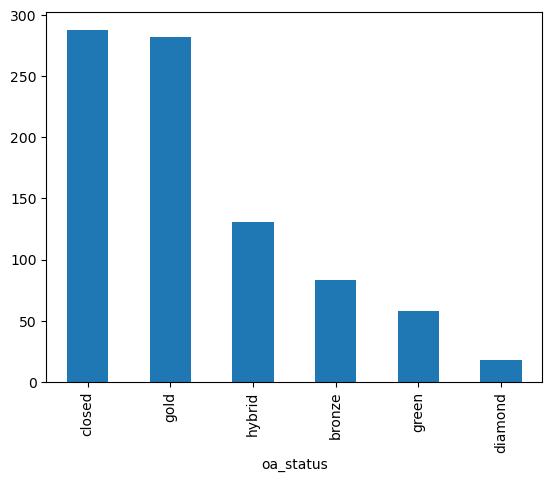

In [88]:
print(df_filtered.is_oa.value_counts())
df_filtered.oa_status.value_counts()
df_filtered.oa_status.value_counts().plot(kind='bar')
plt.show()


In [89]:
#OpenAlex Id
print(df_filtered.openalex_id.describe())
print(f'NaN values: {df_filtered.openalex_id.isna().sum()}')
print(f'Duplicated ID: {df_filtered.openalex_id.duplicated().sum()}')

count             860
unique            854
top       W2897765874
freq                3
Name: openalex_id, dtype: object
NaN values: 0
Duplicated ID: 6


count    225.000000
mean       3.822222
std       12.872467
min        1.000000
25%        1.000000
50%        1.000000
75%        3.000000
max      183.000000
Name: count, dtype: float64


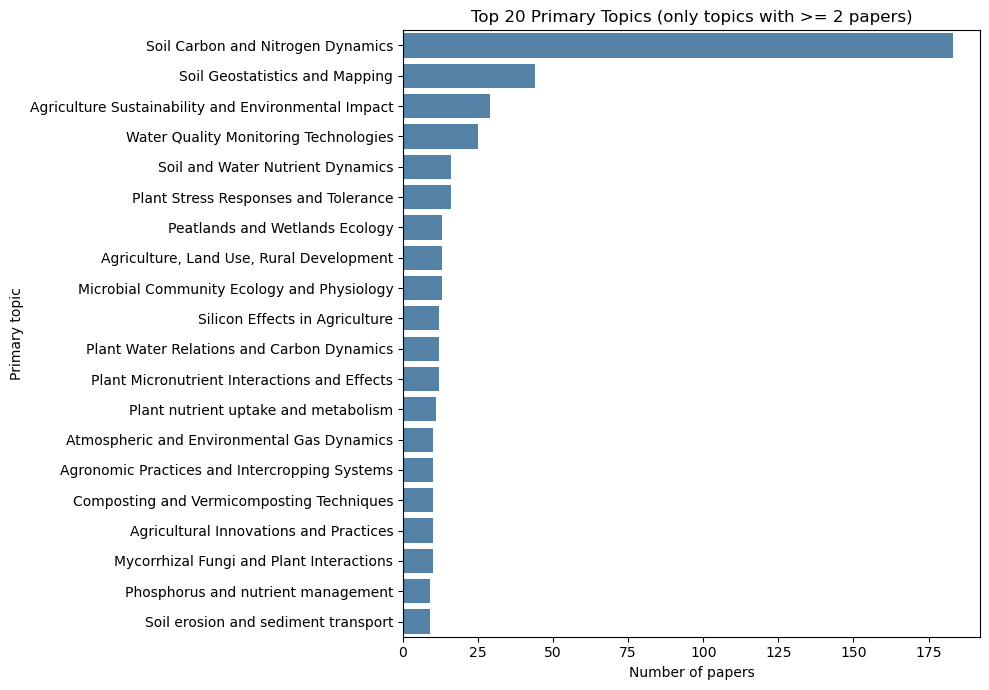

In [90]:
# 1) Count topics
topic_counts = (df_filtered["primary_topic_name"].value_counts())
print(topic_counts.describe())
# 2) Remove rare topics (example: keep topics with at least 2 papers)
min_count = 2
topic_counts_filtered = topic_counts[topic_counts >= min_count]
# 3) Keep top N for readability
top_n = 20
top_topics = topic_counts_filtered.head(top_n)
# 4) Plot
plt.figure(figsize=(10, 7))
sns.barplot(
    x=top_topics.values,
    y=top_topics.index,
    orient="h",
    color="steelblue"
)
plt.title(f"Top {top_n} Primary Topics (only topics with >= {min_count} papers)")
plt.xlabel("Number of papers")
plt.ylabel("Primary topic")
plt.tight_layout()
plt.show()

In [91]:
def extract_unique_sdg_names(x):
    if pd.isna(x):
        return None
    try:
        parsed = ast.literal_eval(x) if isinstance(x, str) else x
        if not isinstance(parsed, list):
            return None
        # canonical map: lowercase -> first seen "nice" casing
        canon = {}
        for d in parsed:
            if isinstance(d, dict):
                name = d.get("display_name")
                if isinstance(name, str):
                    clean = " ".join(name.split()).strip()          # remove extra spaces
                    key = clean.casefold()                           # case-insensitive key
                    if key and key not in canon:
                        canon[key] = clean.title()                   # standardize case
        if not canon:
            return None
        # sort so "A, B" and "B, A" become identical
        return ", ".join(sorted(canon.values()))
    except Exception:
        return None
df_filtered["sdg_names"] = df_filtered["sustainable_development_goals"].apply(extract_unique_sdg_names)

sdg_names_list
Zero Hunger                               258
Life In Land                              209
Clean Water And Sanitation                 60
Climate Action                             50
Life Below Water                           38
Responsible Consumption And Production     34
No Poverty                                  7
Affordable And Clean Energy                 5
Industry                                    5
Innovation And Infrastructure               5
Sustainable Cities And Communities          4
Partnerships For The Goals                  4
Good Health And Well-Being                  2
Gender Equality                             2
Peace                                       1
Name: count, dtype: int64


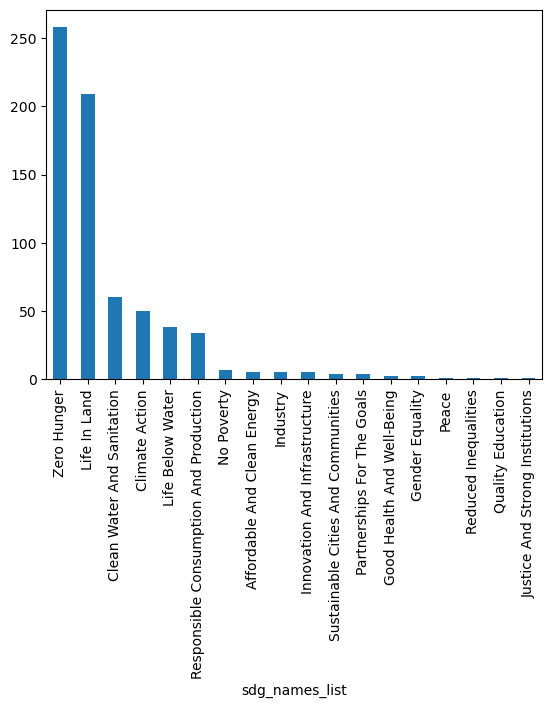

In [92]:
def extract_unique_sdg_list(x):
    s = extract_unique_sdg_names(x)
    return s.split(", ") if isinstance(s, str) else []

df_filtered["sdg_names_list"] = df_filtered["sustainable_development_goals"].apply(extract_unique_sdg_list)

sdg_counts = (
    df_filtered["sdg_names_list"]
    .explode()
    .dropna()
    .value_counts()
)

print(sdg_counts.head(15))
sdg_counts.plot(kind='bar')
plt.show()

count     860.000000
mean     2020.447674
std         1.682840
min      2018.000000
25%      2019.000000
50%      2020.000000
75%      2022.000000
max      2023.000000
Name: publication_year, dtype: float64


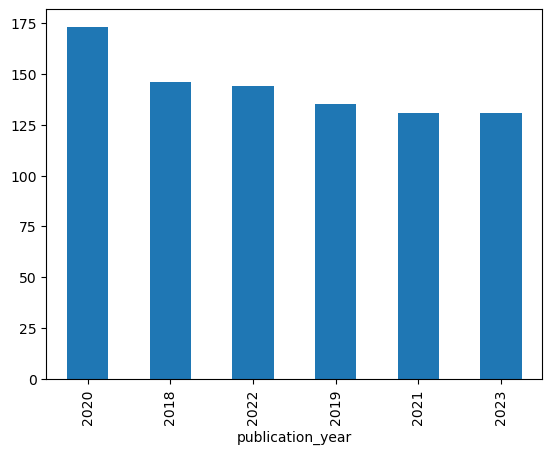

In [93]:
print(df_filtered.publication_year.describe())
df_filtered.publication_year.value_counts().plot(kind='bar')
plt.show()


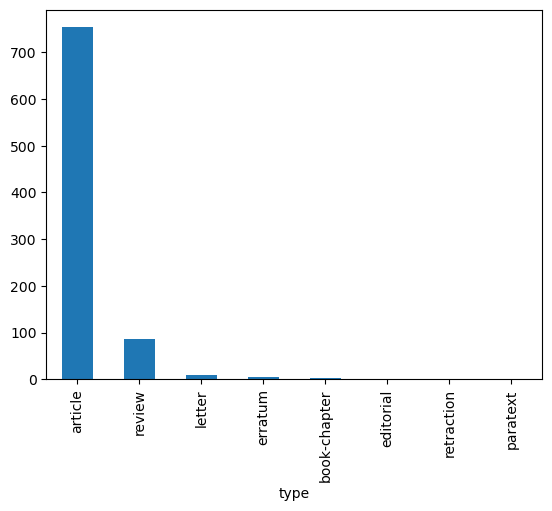

In [94]:
df_filtered.type.value_counts()
df_filtered.type.value_counts().plot(kind='bar')
plt.show()

count     860.000000
mean       70.882558
std        70.353284
min         0.000000
25%        38.000000
50%        58.000000
75%        85.000000
max      1382.000000
Name: referenced_works_count, dtype: float64
referenced_works_count
0      35
53     19
50     17
49     15
14     15
       ..
218     1
168     1
319     1
258     1
312     1
Name: count, Length: 199, dtype: int64


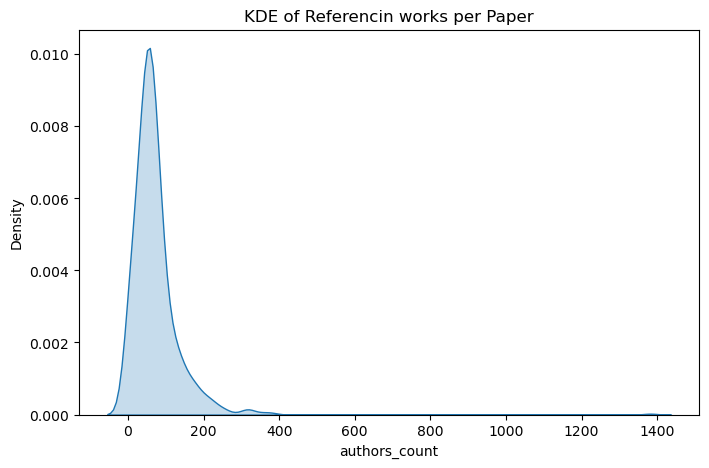

In [95]:
#Yo mismo verifique el numero de referenced works y si es 1382
print(df_filtered.referenced_works_count.describe())
print(df_filtered.referenced_works_count.value_counts())
plt.figure(figsize=(8, 5))
sns.kdeplot(df_filtered.referenced_works_count, fill=True, bw_adjust=1.0)
plt.title("KDE of Referencin works per Paper")
plt.xlabel("authors_count")
plt.ylabel("Density")
plt.show()

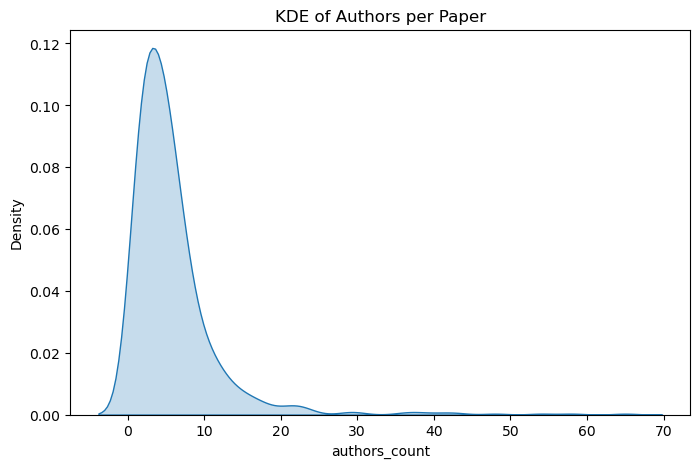

In [96]:
authors = pd.to_numeric(df_filtered["authors_count"], errors="coerce").dropna()
plt.figure(figsize=(8, 5))
sns.kdeplot(authors, fill=True, bw_adjust=1.0)
plt.title("KDE of Authors per Paper")
plt.xlabel("authors_count")
plt.ylabel("Density")
plt.show()

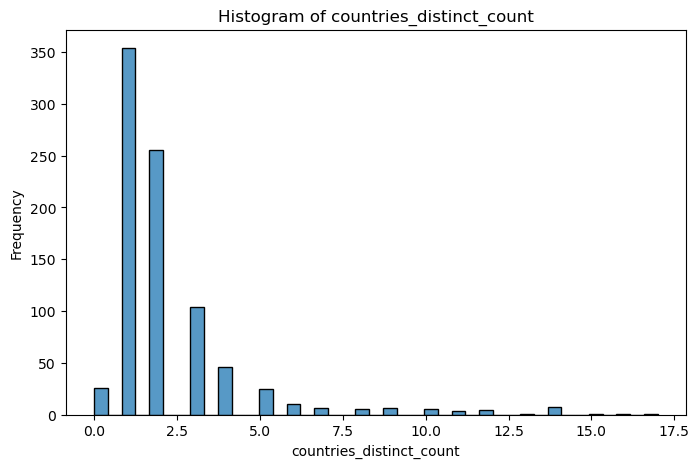

In [97]:
countries = pd.to_numeric(df_filtered["countries_distinct_count"], errors="coerce").dropna()
plt.figure(figsize=(8, 5))
sns.histplot(countries)
plt.title("Histogram of countries_distinct_count")
plt.xlabel("countries_distinct_count")
plt.ylabel("Frequency")
plt.show()

In [98]:
import ast
import re

# 1. Extract + normalize in one step
def extract_keywords(keyword_str):
    try:
        data = ast.literal_eval(keyword_str)
        cleaned = []
        for item in data:
            kw = item["display_name"].lower()
            kw = re.sub(r"\(.*?\)", "", kw)  # remove parentheses
            kw = kw.strip()
            cleaned.append(kw)
        return cleaned
    except:
        return []

df_filtered = df_filtered.copy()  # IMPORTANT
df_filtered["keywords"] = df_filtered["keywords"].apply(extract_keywords)





In [99]:
print(df_filtered.shape)
df_filtered.to_csv(r'C:\Users\locos\Documents\Code\Ciampitti-Lab\PublicationAnalysis\data\machine_learning_data\data_ready_for_ml')

(860, 47)
